In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import random
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset
from trainer_class import Trainer

from ResNet import ResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def plot_metrics(class_names, num_epochs, results_dict, title_str, savefile=None):

    epochs_list = np.arange(1, num_epochs+1)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_list, results_dict["train_loss"], '.-', label="train loss")
    plt.plot(epochs_list, results_dict["val_loss"], '.-', label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()    

    plt.subplot(2, 2, 2)
    plt.plot(epochs_list, results_dict["train_acc"], '.-', label="train acc")
    plt.plot(epochs_list, results_dict["val_acc"], '.-', label="val acc")
    plt.plot(epochs_list, results_dict["val_mAP"], '.-', label="val mAP")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(2, 2, 3) 
    hist_arr_val_acc_per_class = np.asarray(results_dict["val_acc_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_acc_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy, validation set")
    plt.legend()


    plt.subplot(2, 2, 4) 
    hist_arr_val_AP_per_class = np.asarray(results_dict["val_AP_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_AP_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Average precision, validation set")
    plt.legend()
     
    plt.suptitle(title_str, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if savefile:
        plt.savefig(savefile, bbox_inches="tight")
    
    plt.show()

Device: cuda


In [3]:
set_seed(42)

DATASET_PATH = r"/itf-fi-ml/shared/courses/IN3310/mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(class_names, class_filenames)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=transform)

# --------------------------------------------------------------------------------------------------------------------------------

BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, -1.0, 1.0)

# --------------------------------------------------------------------------------------------------------------------------------

In [4]:
model_ResNet18 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18.parameters(), lr=1e-4)

trainer_ResNet18 = Trainer(
    model=model_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet18_lr00004_std002",
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet18.fit(train_loader, val_loader, epochs=num_epochs)

trainer_ResNet18.evaluate(test_loader)

# Move results from GPU to memory
results_dict = trainer_ResNet18.history

Epoch 01 | train loss: 0.7321, acc: 0.724 | val loss: 0.7083, acc: 0.747, acc_per_class: [0.6455696  0.92705166 0.8873239  0.6895604  0.53592813 0.7919075 ], mean average precision (mAP): 0.856, AP per class: [0.8169913  0.97574723 0.83176775 0.81305702 0.81917244 0.88070342]
Epoch 02 | train loss: 0.4765, acc: 0.824 | val loss: 0.4711, acc: 0.833, acc_per_class: [0.76582277 0.9513678  0.6732394  0.79395604 0.9191617  0.9046243 ], mean average precision (mAP): 0.912, AP per class: [0.89510082 0.98765109 0.87906109 0.86620621 0.92654762 0.91964572]
Epoch 03 | train loss: 0.3784, acc: 0.864 | val loss: 0.9663, acc: 0.719, acc_per_class: [0.5221519 0.993921  0.6422535 0.8076923 0.9011976 0.4479769], mean average precision (mAP): 0.849, AP per class: [0.79193847 0.9342155  0.85911863 0.84211529 0.93820765 0.72717919]
Epoch 04 | train loss: 0.2826, acc: 0.900 | val loss: 0.7313, acc: 0.774, acc_per_class: [0.9240506  0.9513678  0.52112675 0.7692308  0.8263473  0.6849711 ], mean average prec

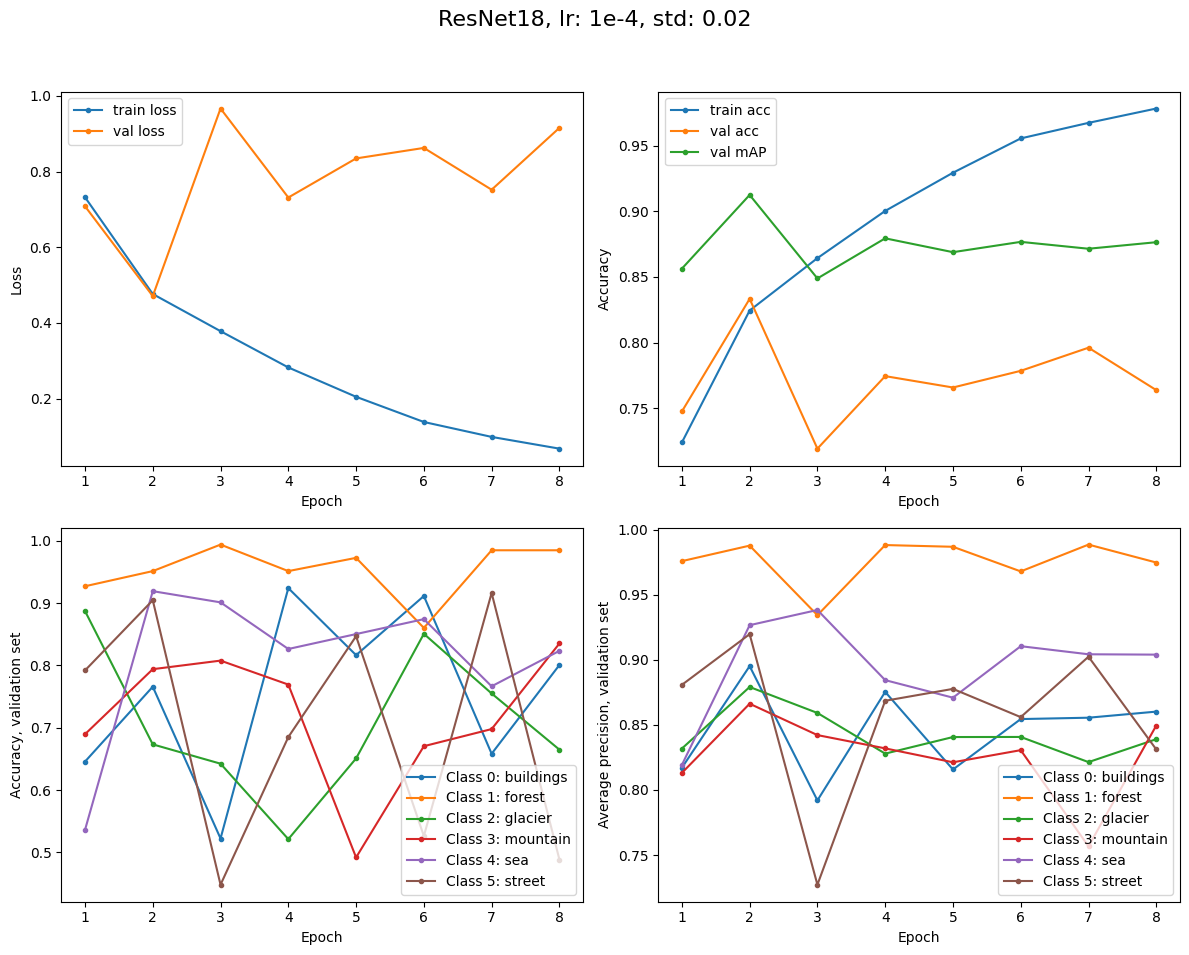

In [13]:
plot_metrics(class_names, num_epochs, results_dict, f"ResNet18, lr: 1e-4, std: 0.02",savefile="ResNet18_lr00004_std002.pdf")

In [17]:
# ResNet model 2:

model_ResNet18_2 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18_2.parameters(), lr=1e-3)

trainer_ResNet18_2 = Trainer(
    model=model_ResNet18_2,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet18_2_lr0001_std005",
    augment_fn=lambda x: batch_noise_augment(x, std=0.05),
)

trainer_ResNet18_2.fit(train_loader, val_loader, epochs=num_epochs)

trainer_ResNet18_2.evaluate(test_loader)

# Move results from GPU to memory
results_dict_2 = trainer_ResNet18_2.history

Epoch 01 | train loss: 0.9159, acc: 0.648 | val loss: 0.7898, acc: 0.713, acc_per_class: [0.8259494  0.7234042  0.6225352  0.54395604 0.8473054  0.74277455], mean average precision (mAP): 0.811, AP per class: [0.79396885 0.95223772 0.78341586 0.71916404 0.82333099 0.79218195]
Epoch 02 | train loss: 0.6317, acc: 0.763 | val loss: 1.1562, acc: 0.596, acc_per_class: [0.51582277 0.65045595 0.4225352  0.21703297 0.98203593 0.82080925], mean average precision (mAP): 0.791, AP per class: [0.79384087 0.94535511 0.64656801 0.79475357 0.80728797 0.76031527]
Epoch 03 | train loss: 0.5471, acc: 0.803 | val loss: 0.5086, acc: 0.821, acc_per_class: [0.73101264 0.88145894 0.7859155  0.69505495 0.9071856  0.9306358 ], mean average precision (mAP): 0.903, AP per class: [0.88538968 0.97595452 0.86298637 0.86678229 0.90059054 0.92499552]
Epoch 04 | train loss: 0.4937, acc: 0.823 | val loss: 0.5969, acc: 0.785, acc_per_class: [0.74050635 0.9726444  0.67887324 0.92582417 0.57185626 0.8150289 ], mean averag

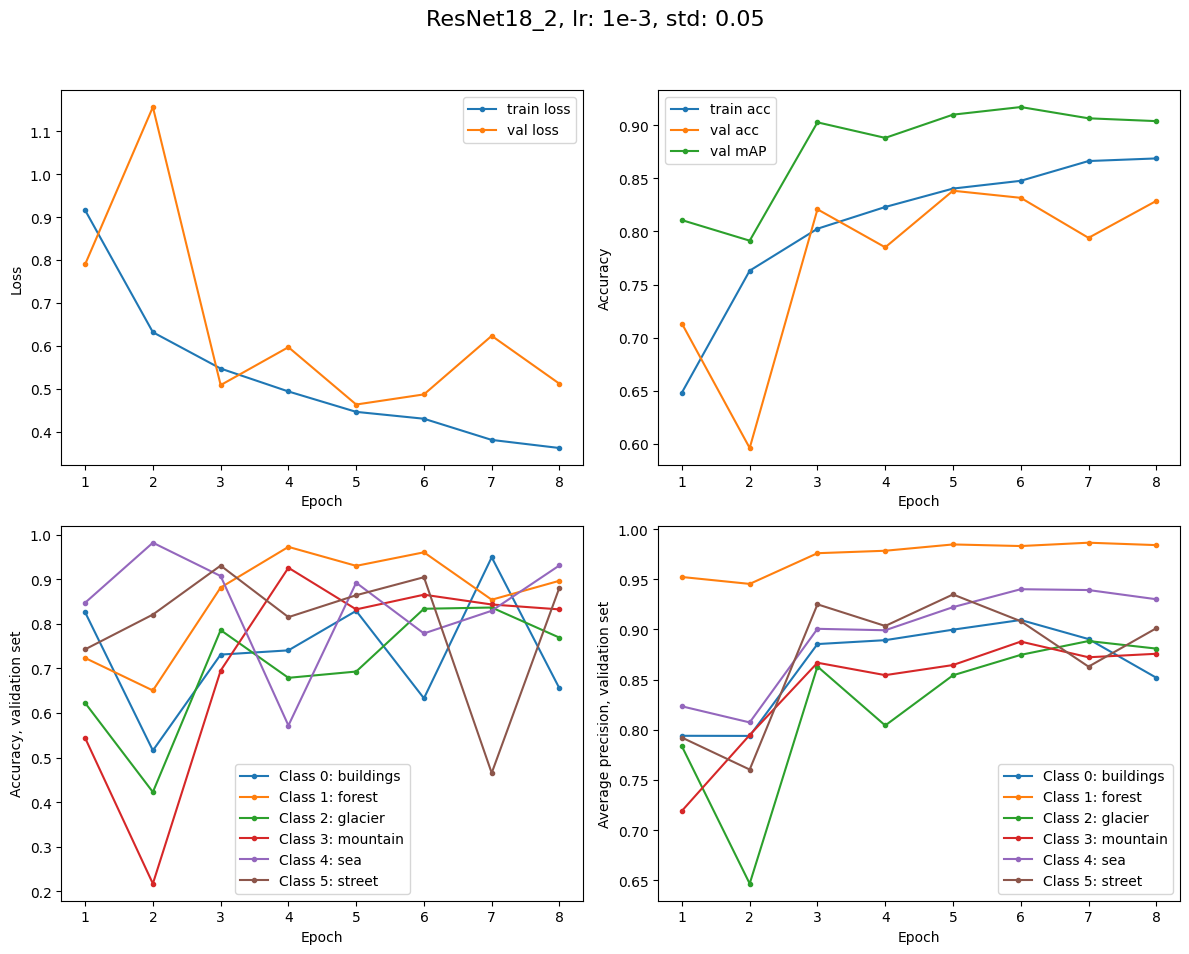

In [18]:
plot_metrics(class_names, num_epochs, results_dict_2, "ResNet18_2, lr: 1e-3, std: 0.05", savefile="ResNet18_2_lr0001_std005.pdf")

In [8]:
# ResNet model 3:

model_ResNet18_3 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18_3.parameters(), lr=1e-3)

trainer_ResNet18_3 = Trainer(
    model=model_ResNet18_3,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet18_3_lr0001_std01",
    augment_fn=lambda x: batch_noise_augment(x, std=0.5),
)

trainer_ResNet18_3.fit(train_loader, val_loader, epochs=num_epochs)

# Move results from GPU to memory
results_dict_3 = trainer_ResNet18_3.history

Epoch 01 | train loss: 1.0245, acc: 0.605 | val loss: 2.1997, acc: 0.369, acc_per_class: [0.70253164 0.14589666 0.         0.95604396 0.0239521  0.3699422 ], mean average precision (mAP): 0.459, AP per class: [0.60324006 0.84546934 0.15556557 0.54880103 0.18956728 0.40897284]
Epoch 02 | train loss: 0.7427, acc: 0.727 | val loss: 1.1428, acc: 0.576, acc_per_class: [0.64873415 0.3586626  0.14647888 0.7005494  0.76047903 0.849711  ], mean average precision (mAP): 0.721, AP per class: [0.75457388 0.87937798 0.71724995 0.69101379 0.65574411 0.62817214]
Epoch 03 | train loss: 0.6508, acc: 0.757 | val loss: 1.4968, acc: 0.460, acc_per_class: [0.8955696  0.3130699  0.45633802 0.09615385 0.71556884 0.34104046], mean average precision (mAP): 0.616, AP per class: [0.71933388 0.87000772 0.57624718 0.53278033 0.54367074 0.45471999]
Epoch 04 | train loss: 0.5737, acc: 0.792 | val loss: 1.1500, acc: 0.587, acc_per_class: [0.84810126 0.4832827  0.12676056 0.7197802  0.6497006  0.716763  ], mean averag

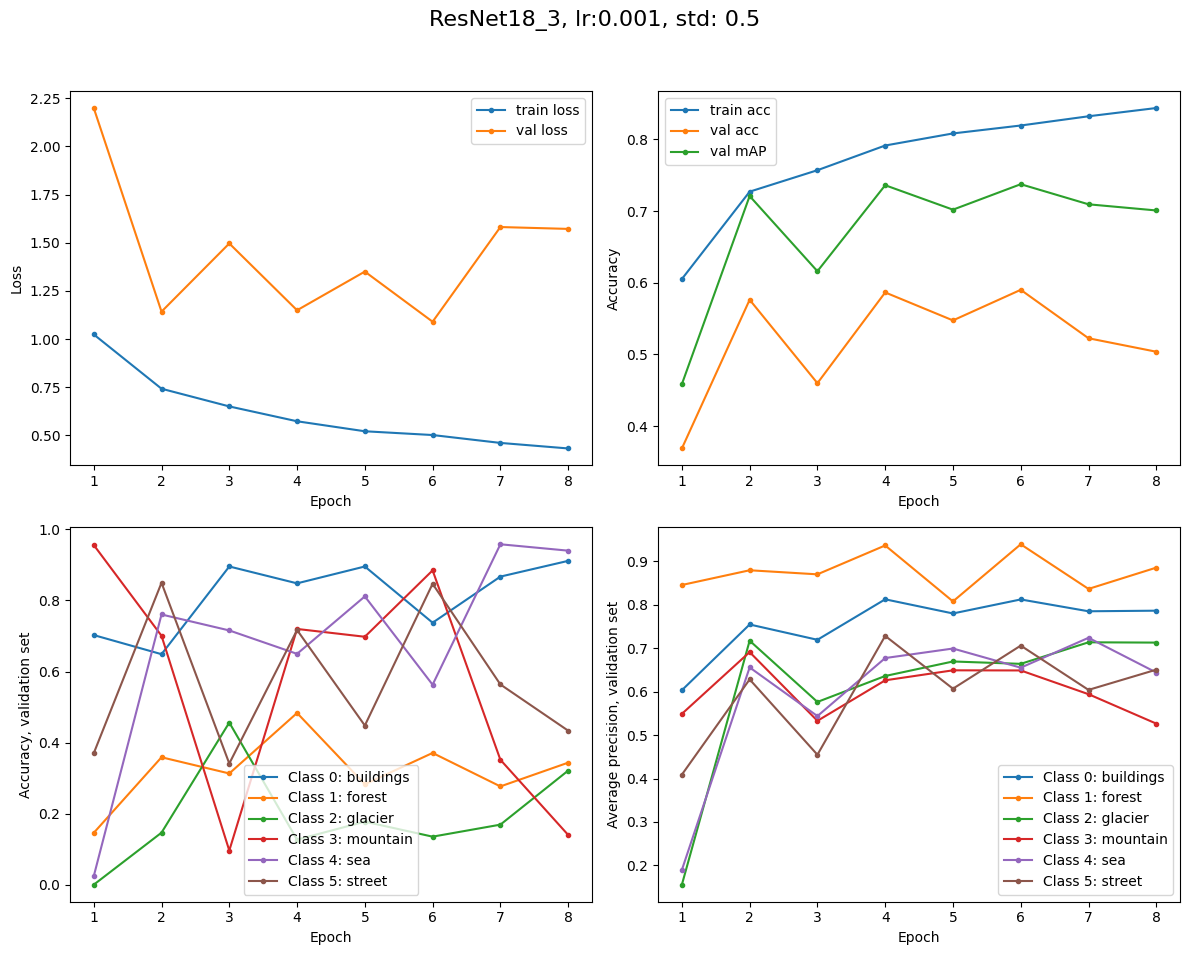

In [15]:
plot_metrics(class_names, num_epochs, results_dict_3, "ResNet18_3, lr:0.001, std: 0.5", savefile="ResNet18_3_lr0001_std01.pdf")

# Load model evaluation on test data

In [21]:
model_ResNet18_loaded = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)
model_ResNet18_loaded.load_state_dict(torch.load("ResNet18_2_lr0001_std005_best_weights.pth", weights_only=True))
model_ResNet18_loaded.eval()

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18.parameters(), lr=1e-4)

trainer_ResNet_loaded = Trainer(
    model=model_ResNet18_loaded,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet_lr00004_std002",
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet_loaded.evaluate(test_loader)


EpochStats(loss=0.4830149409050743, acc=0.8328147071103255, mAP=0.9127676749129137, acc_per_class=array([0.6638478 , 0.96363634, 0.84210527, 0.83729434, 0.7884232 ,
       0.89017344], dtype=float32), AP_per_class=array([0.91878807, 0.97872524, 0.87712846, 0.87417787, 0.929399  ,
       0.89838741]))

# torchvison model

In [22]:
# Imported pretrained ResNet18 model from torchvision
# Change from 1000 to 6 outputs in last layer
model_torch_ResNet18 = torchvision.models.resnet18(weights="ResNet18_Weights.DEFAULT")
num_features = model_torch_ResNet18.fc.in_features
print(model_torch_ResNet18.fc.out_features)
model_torch_ResNet18.fc = nn.Linear(num_features, 6)
print(model_torch_ResNet18.fc.out_features)

1000
6


In [23]:
num_epochs = 8

model_torch_ResNet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_torch_ResNet18.parameters(), lr=1e-4)

trainer_model_torch_ResNet18 = Trainer(
    model=model_torch_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="torch_ResNet18_lr00001_std002_best_weights",
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_model_torch_ResNet18.fit(train_loader, val_loader, epochs=num_epochs)

# Move results from GPU to memory
results_dict_torch_ResNet18 = trainer_model_torch_ResNet18.history

Epoch 01 | train loss: 0.3103, acc: 0.895 | val loss: 0.2117, acc: 0.926, acc_per_class: [0.9177215  0.993921   0.88450706 0.84615386 0.97904193 0.94219655], mean average precision (mAP): 0.973, AP per class: [0.97443059 0.99989103 0.94078813 0.94745316 0.99381764 0.984413  ]
Epoch 02 | train loss: 0.0928, acc: 0.970 | val loss: 0.2740, acc: 0.914, acc_per_class: [0.95253164 0.99696046 0.72112674 0.9423077  0.98502994 0.9017341 ], mean average precision (mAP): 0.965, AP per class: [0.96908947 0.99987522 0.92227066 0.92164475 0.994733   0.98245224]
Epoch 03 | train loss: 0.0371, acc: 0.990 | val loss: 0.2643, acc: 0.935, acc_per_class: [0.87974685 0.98784196 0.87042254 0.91483516 0.98802394 0.97109824], mean average precision (mAP): 0.968, AP per class: [0.96895952 0.99961959 0.93168823 0.92802995 0.99398062 0.98274865]
Epoch 04 | train loss: 0.0227, acc: 0.994 | val loss: 0.2826, acc: 0.929, acc_per_class: [0.914557   0.993921   0.8338028  0.9203297  0.9700599  0.95086706], mean averag

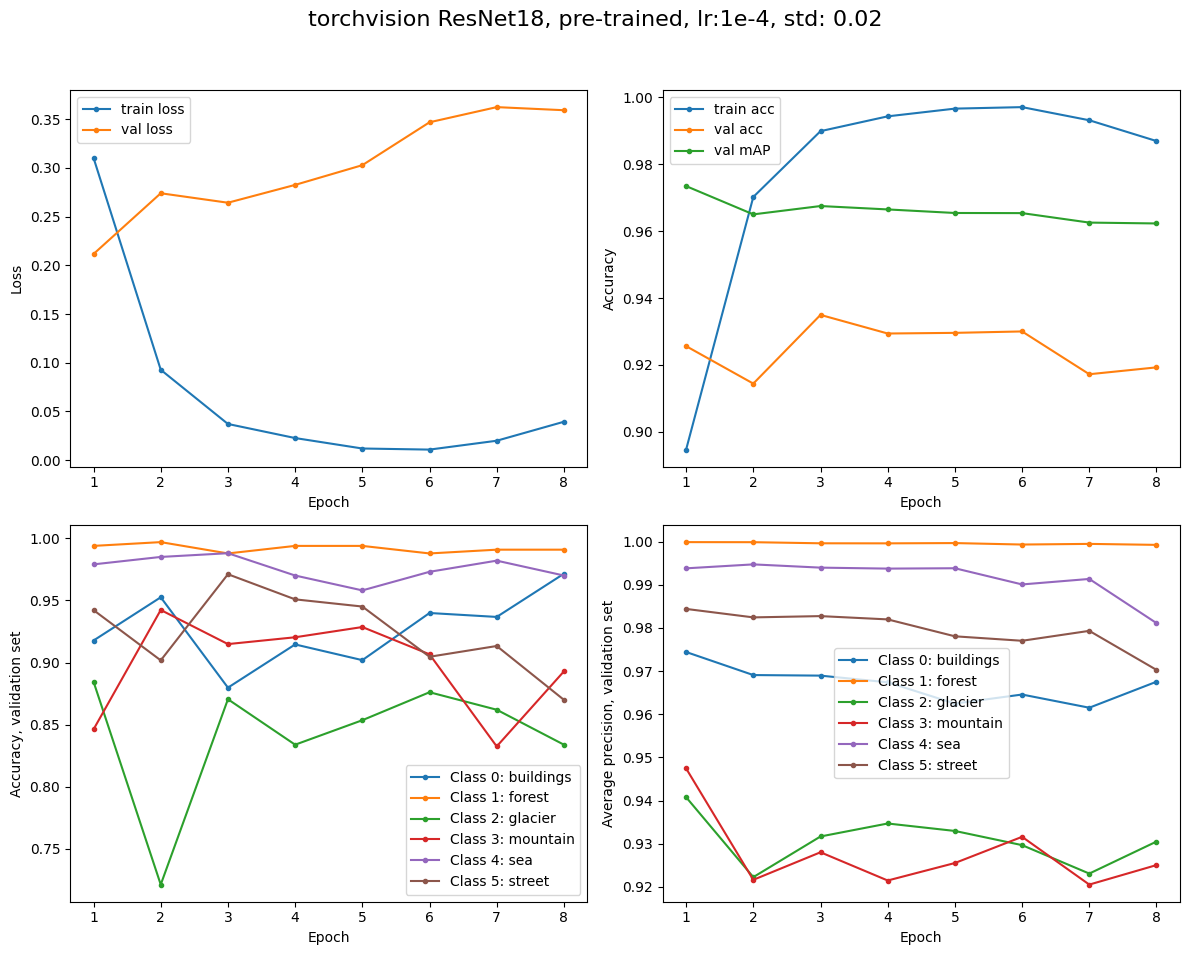

In [24]:
plot_metrics(class_names, num_epochs, results_dict_torch_ResNet18, "torchvision ResNet18, pre-trained, lr:1e-4, std: 0.02", savefile="torchvision_resnet18.pdf")